# A Basic Overview

dLux is a differentiable physical optical modelling framework built within the [Jax](https://github.com/jax-ml/jax)+[Equinox](https://github.com/patrick-kidger/equinox)+[Zodiax](https://github.com/LouisDesdoigts/zodiax) ecosystem, providing differentiability, GPU acceleration, a friendly object-oriented API, as well as a series of optimisation and inference tools and utilities designed for scientific programming. It is designed to be incredibly fast, flexible, and extensible, serving as framework to solve real-world optical problems within, rather than just another optical simulator. It was built for the modelling of astronomical telescopes, but the tools it provides and its flexible construction make it applicable to optical problems well beyond this domain.

Under the hood, dLux takes inspiration from the isomorphic nature between optical system and neural networks, enabling the description of arbitrary optical systems as a series of layers that operate sequentially on a wavefront. This 'layers based' design provides near-complete flexibility to end users (since you can easily define your own layer!), while also enabling most optical systems to be composed from layers that are already implemented within dLux. Unlike other optical simulators, dLux aims to put tools in users hands and teach them how to use them, not provide a pre-built system that works in unknown ways with unknown side-effects! This formulation provides far more power than traditional optical simulators, but also requires a bit more work to get up and running. 

This tutorial is designed to give users a basic introduction to the core parts of dLux. We will cover how to create an optical system and its psf, how to work with dLux objects, and show a basic optimisation workflow. It will be broken down into the following sections:

1. Building an Optical System
2. Simulating Data
3. A Basic Optimisation Workflow

In [1]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax.tree as jtu

# Optimisation imports
import equinox as eqx
import zodiax as zdx
import optax

# dLux imports
import dLux as dl
import dLux.utils as dlu

In [2]:
# Visualisation imports
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import CenteredNorm

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 90

# Nan friendly colormapping
inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

---

## Building an Optical System

Lets start by taking a look at how to build an optical system in dLux, we will focus on the `AngularOpticalSystem` class as it is the most-common for astronomical problems. As mentioned above, dLux optical systems are built from a series of layers that operate sequentially on a wavefront. Each layer is designed to represent a specific transformation to the wavefront, such as encountering an aperture, phase aberration, or propagating to focus. By combining these layers together, we can build up complex optical systems that can model real-world telescopes and instruments.

Beyond the layers themselves, we also need to define a few other properties of the optical system. In order to construct at wavefront at the aperture of the telescope we need to define its diameter, and the number of pixels used to represent the wavefront. To propagate the wavefront to the focal plane, we also need to define the pixel scale of the PSF, and the number of pixels used to represent the PSF.

For this problem, we will build a Euclid-like optical system, since the asymmetry of its aperture makes recovering even Zernike modes easy! Rather than looking at how to build this aperture from scratch here (since we have tutorials on that [here](https://louisdesdoigts.github.io/dLux/tutorials/howtos/custom_apertures/)), we will use a helper function that constructs the aperture for us, imported from the local `optics.py` file. Using this optical system we will model an PSF with optical aberrations and show how we can recover these aberrations directly. 

Lets look at how to build this optical system, starting by getting the different pieces we need together

In [3]:
# from optics import euclid_aperture

# Define our wavefront properties
wf_npix = 256  # Number of pixels in the wavefront
diameter = 1.0  # Diameter of the wavefront, meters

# Define our detector properties
psf_npix = 64  # Number of pixels in the PSF
psf_pixel_scale = 50e-3  # 50 mili-arcseconds

# Construct our Euclid-like aperture
# Generate a euclid-like aperture and Zernike
aperture, basis = dlu.euclid_like(
    npixels=wf_npix,
    diameter=1.1,
    oversample=5,  # Oversampling factor
    secondary_diameter=0.25,  # Diameter of the secondary mirror in meters
    spider_width=0.075,  # Width of the spiders in meters
    zernike_nolls=np.arange(20) + 2  # Skip piston
)

# Normalise the basis to nm and generate some random coefficients
basis *= 1e-9
coeffs = 50 * jr.normal(jr.key(0), basis.shape[0])

Now that we have the bits we need to define our optical system, lets see how we can actually construct it with our variables and layers. There are two layers we are going to need here, the `TransmissiveLayer` and the `BasisLayer`. These will be used to apply our aperture and our optical aberrations respectively. 

We define these layers using a list, ordered in the sequence in which we would like to apply them. While we can pass in the layer directly, its helpful to pass in a tuple pair of `(key, layer)`, as this lets us specify a key that we can use to reference that layer directly, giving us a nicer way to interact with our resutling `OpticalSystem` object.

In [4]:
# Define our aperture layer - note the normalise tells the optical system to normalise
# the wavefront at this layer.
aperture = dl.layers.TransmissiveLayer(transmission=aperture, normalise=True)

# Define our aberrations layer, this will apply our basis as an OPD to the wavefront
aberrations = dl.layers.BasisLayer(basis=basis, coefficients=coeffs)

# Define the optical layers
layers = [
    ("aperture", aperture),
    ("aberrations", aberrations),
]

# Construct the optics object
optics = dl.AngularOpticalSystem(
    wf_npixels=wf_npix, 
    diameter=diameter, 
    layers=layers, 
    psf_npixels=psf_npix, 
    psf_pixel_scale=psf_pixel_scale
)

# Examine the optics object
print(optics)

AngularOpticalSystem(
  wf_npixels=256,
  diameter=1.0,
  layers={
    'aperture': TransmissiveLayer(transmission=f32[256,256], normalise=True),
    'aberrations':
    BasisLayer(basis=f32[20,256,256], coefficients=f32[20], as_phase=False)
  },
  psf_npixels=64,
  oversample=1,
  psf_pixel_scale=0.05
)


Great, as we can see, we now have an optical system object! As you can see dLux objects have pretty-printing syntax (inherited from Equinox) that gives us a nice summary of the object and its properties. This becomes very helpful to understand, manipulate, and work with our classes and highlights one of the core ethos' of dLux - transparency. We want users to understand what is going on under the hood, never do anything 'magic' or hidden, and to be able to interact with it in a way that is intuitive and easy to understand. Now lets see how we can use it!


With our optical system defined, we can now propagate a wavefront through it to get a PSF. The core function for this is the `propagate` method, letting us throw whatever wavelengths we would like through the system. Lets see what this looks like in practice.

In [5]:
# Define the spectral properties of our source for the propagation
wavels = 1e-6 * np.linspace(0.75, 1, 5)
weights = np.linspace(0.5, 1, len(wavels))
weights /= weights.sum()

# Propagate through the system to get the PSF
psf = optics.propagate(wavels, weights=weights)

---

## Simulating Data

Now that we have a psf, we can use it to simulate some data that we will recover the optical aberrations from. We will do this using the jax.random module to add some noise. This is important when simulating systems as otherwise our model can represent our data to machine precision and the optimisation will never really converge!

To make this a realistic simulation we need to add some flux to our PSF, as well as some read noise from the detector. Since we already normalised our optical system at the aperture layer, our PSF represents the probability distribution of one photon passing through the aperture. This means that our recovered fluxes will represent the amount of photons passing through the aperture, so we can map this to a real flux using the collecting area of the aperture. Also, since a non-zero amount of light will diffract beyond the edge of the detector, our PSF sum will always be less than zero, which is representative of the real world where we never capture all the light from a source.



In [6]:
# Generate the illuminance and define the read noise
flux = 5e5
illumination = flux * psf  # Put 1 million photons through the aperture
read_noise = 10.0  # 2 electrons of read noise

# Draw the photons and read noise from the appropriate distributions
photons = jr.poisson(jr.key(1), illumination)
read_electrons = read_noise * jr.normal(jr.key(2), illumination.shape)

# Create the data by defining the image as the sum of the photons and the read noise
data = photons + read_electrons

Now that we have our PSF and data, lets visualise this system. This will show how we can extract our aperture transmission and our applied OPDs from the optical system for visualisation purposes!

Note that dLux _raises parameters_ from the layers up to the optical system object - Thats what the layers key is for! This means that we can access the parameters of the layers directly from the optical system rather than referencing all the way through the object. Lets say we wanted to access the aperture transmission array. Normally, we would have to reference it through the entire system like `optics.layers['aperture'].transmission`, but since the parameters are raised, we can just do `optics.aperture.transmission`! This is a small thing, but it makes working with the system much nicer and more intuitive. As we will see soon, this also makes optimising these objects with zodiax much nicer.

dLux will also search through the layers for the attribute that we want, so we can just do `optics.transmission`, however, this can lead to issues if we have multiple layers with the same attribute, so make sure you know where your parameters are coming from if you use this method!

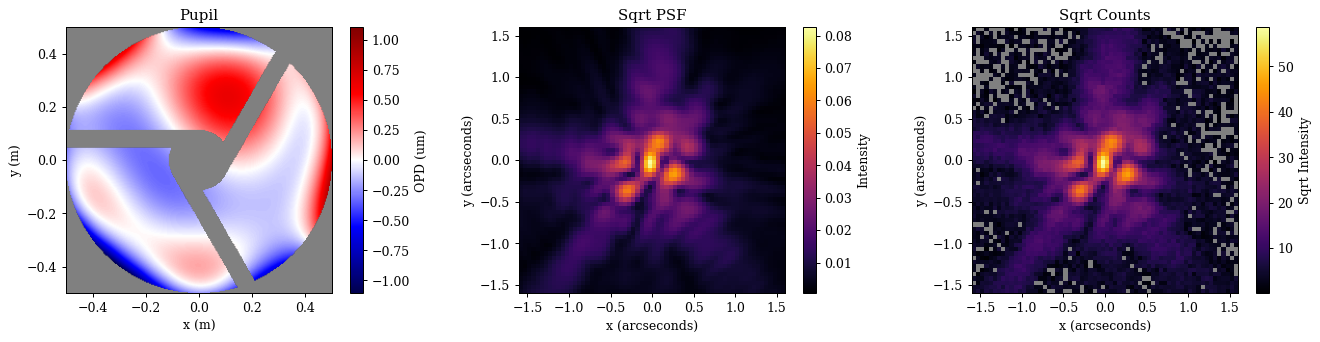

In [7]:
# Get the aperture and OPD for visualisation
opd = 1e6 * optics.aberrations.eval_basis() # Normalise to microns
pupil = opd.at[optics.transmission < 0.5].set(np.nan)

# Get the extents for visualisation
ap_extent = dlu.imshow_extent(optics.diameter)
psf_extent = dlu.imshow_extent(optics.fov)

# Plot the results
plt.figure(figsize=(15, 3.75))
ax = plt.subplot(1, 3, 1)
im = ax.imshow(pupil, seismic, norm=CenteredNorm(), extent=ap_extent)
plt.colorbar(im, ax=ax, label="OPD (um)")
ax.set(title="Pupil", xlabel="x (m)", ylabel="y (m)")

ax = plt.subplot(1, 3, 2)
im = ax.imshow(psf**0.5, inferno, extent=psf_extent)
plt.colorbar(im, ax=ax, label="Intensity")
ax.set(title="Sqrt PSF", xlabel="x (arcseconds)", ylabel="y (arcseconds)")

ax = plt.subplot(1, 3, 3)
im = ax.imshow(data ** 0.5, inferno, extent=psf_extent)
plt.colorbar(im, ax=ax, label="Sqrt Intensity")
ax.set(title="Sqrt Counts", xlabel="x (arcseconds)", ylabel="y (arcseconds)")

plt.tight_layout()
plt.show()

---

## A Basic Optimisation Workflow

Okay this looks good! So of you are likely wondering about the grey pixels in the data, these are the values that are below zero. Since we have added read-noise, some of the pixels have negative values just like we see from real data. When we plot the square root of the data these then become NaNs and therefore are plotted in grey. This is fine though, as we can account for the read-noise in our likelihood function without issue.

Now lets see how we can use our model and this data to recover the optical aberrations! To do this, we first need to set our define our likelihood function and set the initial values of our model. For our likelihood function, since we only have a single image and no uncertainties on them, we can use the PSF of our model to predict the uncertainties on our data and then use a Gaussian likelihood. We also know what our read noise value is, so we can just use this directly. 

For a more complete tutorial on optimisation within the zodiax framework, check out [this tutorial](https://louisdesdoigts.github.io/zodiax/optimisation_tools/). For now, we are going to assume that you have been through that tutorial (although don't worry if you haven't, its all very straight forwards and you should be able to follow without any trouble). Lets see how to set up this likelihood function and optimisation in practice.

In [8]:
def predict_data(params, optics):
    """Predict the data given the current parameters and model"""
    optics = optics.set(coefficients=params["z-coeffs"])
    psf = flux * optics.propagate(wavels, weights=weights)
    error = np.sqrt(psf + read_noise**2)
    return psf, error

def z_score(params, optics, data):
    """Basic z-score function"""
    psf, error = predict_data(params, optics)
    return (data - psf) / error

@eqx.filter_jit
@eqx.filter_value_and_grad
def loss_fn(params, optics, data):
    """Basic loss function"""
    return np.mean(z_score(params, optics, data) ** 2)

# Set up the initial parameters and optimisers
params = {"z-coeffs": np.zeros_like(optics.aberrations.coefficients)}
optimisers = {"z-coeffs": optax.sgd(1e2, momentum=0.5)}
optim, state = zdx.map_optimisers(params, optimisers)

# Now we can run a simple optimisation loop
epochs = 100
pbar = tqdm(range(epochs))
losses, params_history = [], []
for step in pbar:
    loss, grads = loss_fn(params, optics, data)
    updates, state = optim.update(grads, state)
    params = optax.apply_updates(params, updates)
    pbar.set_postfix(log_loss=f"{np.log10(loss):.4f}")
    losses.append(loss)
    params_history.append(params)
losses = np.array(losses)

  0%|          | 0/100 [00:00<?, ?it/s]

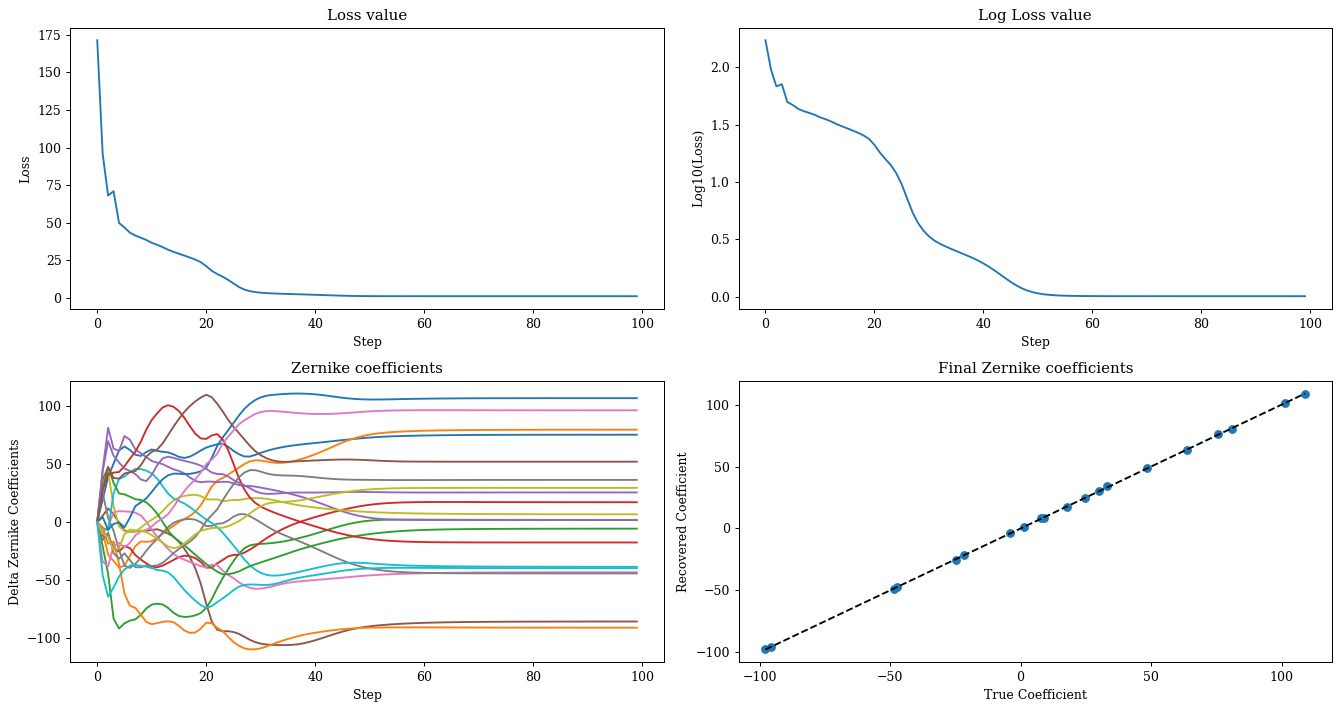

In [9]:
# Map the parameter history to arrays for plotting
z_coeffs = np.array([jtu.leaves(params["z-coeffs"]) for params in params_history])
delta_z = (z_coeffs - z_coeffs[0]).reshape(epochs, -1)

# Plot the losses
plt.figure(figsize=(15, 8))
ax = plt.subplot(2, 2, 1)
ax.plot(losses)
ax.set(title="Loss value", xlabel="Step", ylabel="Loss")

ax = plt.subplot(2, 2, 2)
ax.plot(np.log10(losses))
ax.set(title="Log Loss value", xlabel="Step", ylabel="Log10(Loss)")

ax = plt.subplot(2, 2, 3)
ax.plot(delta_z)
ax.set(title="Zernike coefficients", xlabel="Step", ylabel="Delta Zernike Coefficients")

ax = plt.subplot(2, 2, 4)
ax.scatter(coeffs, z_coeffs[-1])
ax.plot([coeffs.min(), coeffs.max()], [coeffs.min(), coeffs.max()], "k--", label="1:1")
ax.set(title="Final Zernike coefficients", ylabel="Recovered Coefficient", xlabel="True Coefficient")

plt.tight_layout()
plt.show()

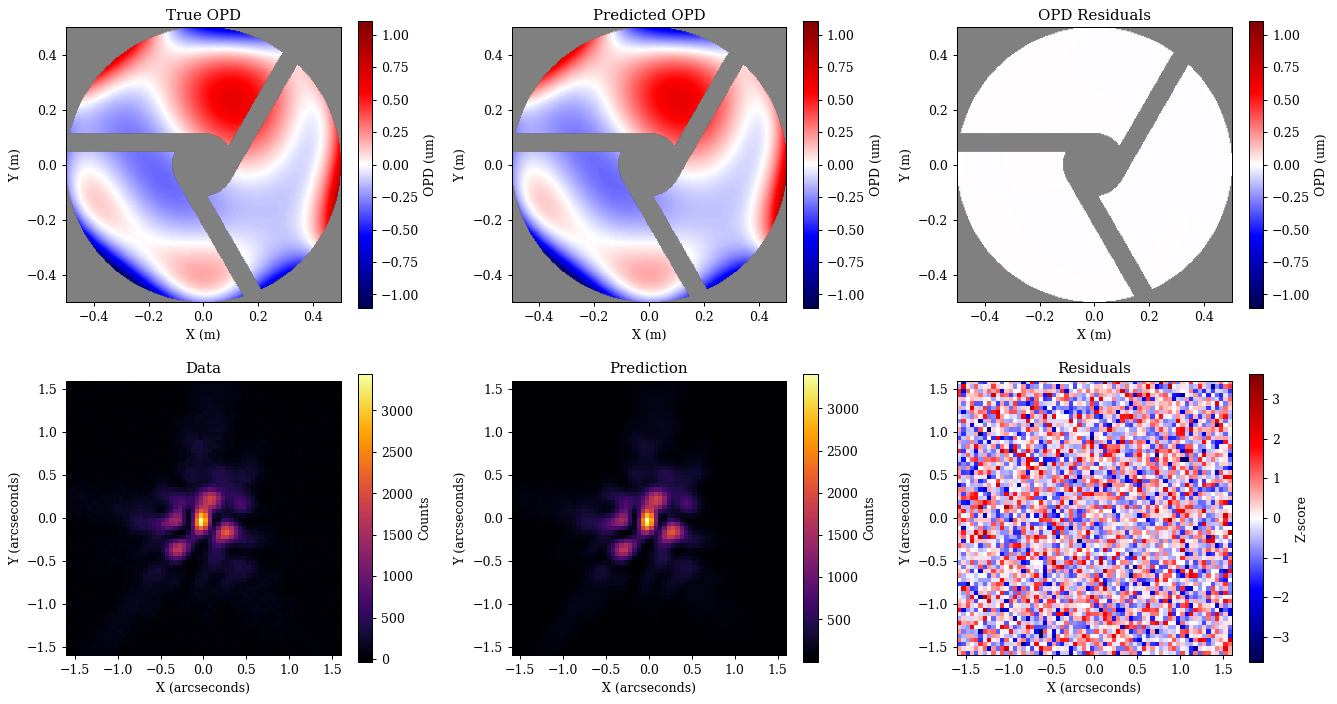

In [10]:
# Get the aperture and OPD for visualisation
pred_opd = 1e6 * optics.set(coefficients=params["z-coeffs"]).aberrations.eval_basis()
pred_pupil = pred_opd.at[optics.transmission < 0.5].set(np.nan)
pupil_residuals = pred_pupil - pupil
v = np.nanmax(np.abs(np.array([pupil, pred_pupil])))

# Get our predicted OPD and data for the final parameters
pred, error = predict_data(params, optics)
z_score = (data - pred) / error

plt.figure(figsize=(15, 8))
ax = plt.subplot(2, 3, 1)
im = ax.imshow(pupil, seismic, vmin=-v, vmax=v, extent=ap_extent)
plt.colorbar(im, ax=ax, label="OPD (um)")
ax.set(title="True OPD", xlabel="X (m)", ylabel="Y (m)")

ax = plt.subplot(2, 3, 2)
im = ax.imshow(pred_pupil, seismic, vmin=-v, vmax=v, extent=ap_extent)
plt.colorbar(im, ax=ax, label="OPD (um)")
ax.set(title="Predicted OPD", xlabel="X (m)", ylabel="Y (m)")

ax = plt.subplot(2, 3, 3)
im = ax.imshow(pupil_residuals, seismic, vmin=-v, vmax=v, extent=ap_extent)
plt.colorbar(im, ax=ax, label="OPD (um)")
ax.set(title="OPD Residuals", xlabel="X (m)", ylabel="Y (m)")

ax = plt.subplot(2, 3, 4)
im = ax.imshow(data, extent=psf_extent)
plt.colorbar(im, ax=ax, label="Counts")
ax.set(title="Data", xlabel="X (arcseconds)", ylabel="Y (arcseconds)")

ax = plt.subplot(2, 3, 5)
im = ax.imshow(pred, extent=psf_extent)
plt.colorbar(im, ax=ax, label="Counts")
ax.set(title="Prediction", xlabel="X (arcseconds)", ylabel="Y (arcseconds)")

ax = plt.subplot(2, 3, 6)
im = ax.imshow(z_score, seismic, norm=CenteredNorm(), extent=psf_extent)
plt.colorbar(im, ax=ax, label="Z-score")
ax.set(title="Residuals", xlabel="X (arcseconds)", ylabel="Y (arcseconds)")

plt.tight_layout()
plt.show()

---

## Building a Custom Layer

In [11]:
# Create a child-class of OpticalLayer, so dLux can recognise it as a layer
class FocalPlaneMsk(dl.layers.optical_layers.OpticalLayer):
    radius: float  # Focal plane mask radius in lambda / D units
    shift: np.ndarray  # Shift of the focal plane mask, in lambda / D units
    scale: float # Size of lambda / D in radians

    def __init__(self, radius=2.0, scale=1., shift=None):
        self.radius = float(radius)
        self.scale = float(scale)
        if shift is None:
            shift = np.zeros(2)
        self.shift = np.array(shift, float)

    def __call__(self, wavefront):
        # FFT to the focal plane
        fp_wf = wavefront.propagate_FFT(pad=4)

        # Apply the focal plane mask and shift for the mask
        fp_coords = fp_wf.coordinates(fft_style=True)
        fp_coords = dlu.translate_coords(fp_coords, -self.shift * self.scale)

        # Calculate the focal plane mask
        softness = 0.5 * fp_wf.pixel_scale
        radius_phys = self.radius * self.scale
        fp_mask = dlu.soft_circle(fp_coords, radius_phys, softness, True)

        # Apply the mask to the focal plane wavefront
        fp_wf *= fp_mask

        # Inverse FFT to the pupil plane and crop
        return fp_wf.propagate_FFT(pad=1).resize(wavefront.npixels)

fpm = FocalPlaneMsk(radius=2, shift=[0, 0], scale=wavels.mean() / diameter)

In [12]:
# Construct a lyot mask
coords = dlu.pixel_coords(wf_npix, diameter)
coron_aper = dlu.circle(coords, diameter / 2)
lyot_aper = dlu.circle(coords, 0.95 * diameter / 2)
# lyot_mask = ~((lyot_aper < 0.5) | (euclid_aper < 0.5))
lyot = dl.layers.TransmissiveLayer(transmission=lyot_aper)

coron_aperture = dl.layers.TransmissiveLayer(transmission=coron_aper, normalise=True)

In [13]:
# Define the optical layers
layers = [
    ("aperture", coron_aperture),
    ("aberrations", aberrations.multiply(coefficients=0.1)),
    ("fpm", fpm),
    ("lyot", lyot),
]

# Construct the optics object
coron = dl.AngularOpticalSystem(
    wf_npixels=wf_npix,
    diameter=diameter,
    layers=layers,
    psf_npixels=psf_npix,
    psf_pixel_scale=psf_pixel_scale,
)

In [14]:
lamd = wavels.mean() / diameter
offsets = np.linspace(0, 4, 5)

psfs = []
for oset in offsets:
    offset = lamd * np.array([oset, 0])
    psf = coron.propagate(wavels, offset, weights=weights)
    psfs.append(psf)
psfs = np.array(psfs)

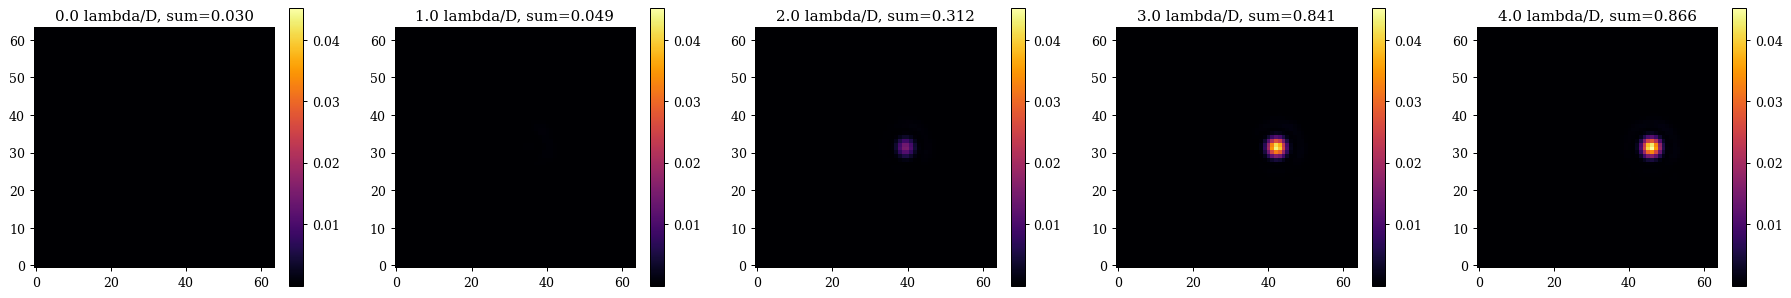

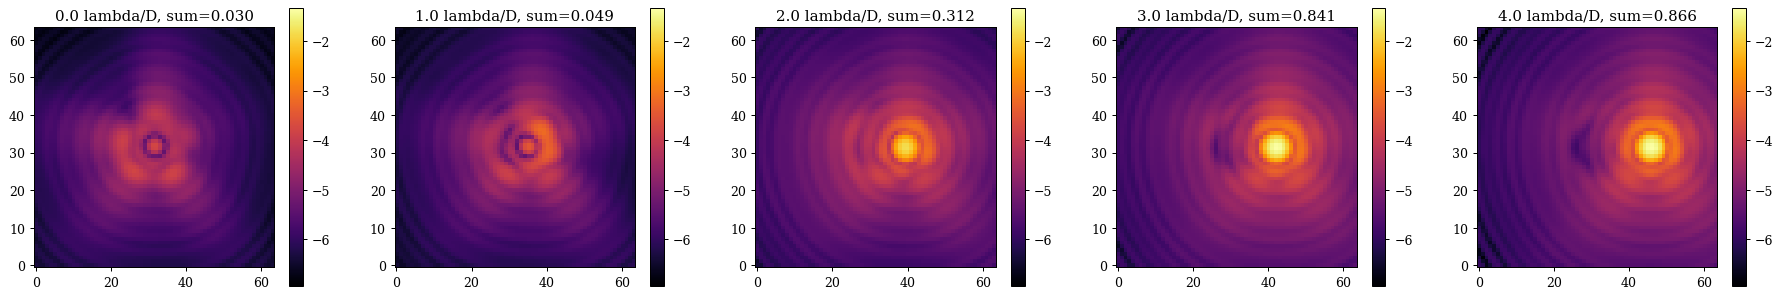

In [15]:
plt.figure(figsize=(25, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.title(f"{offsets[i]:.1f} lambda/D, sum={psfs[i].sum():.3f}")
    plt.imshow(psfs[i], vmax=np.max(psfs))
    plt.colorbar()
plt.show()

plt.figure(figsize=(25, 4))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.title(f"{offsets[i]:.1f} lambda/D, sum={psfs[i].sum():.3f}")
    plt.imshow(
        np.log10(psfs[i]), vmin=np.min(np.log10(psfs)), vmax=np.max(np.log10(psfs))
    )
    plt.colorbar()
plt.show()

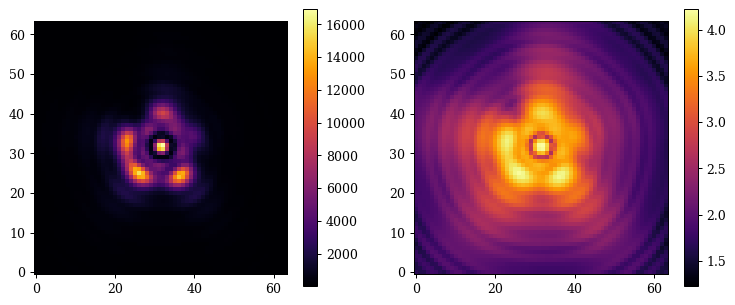

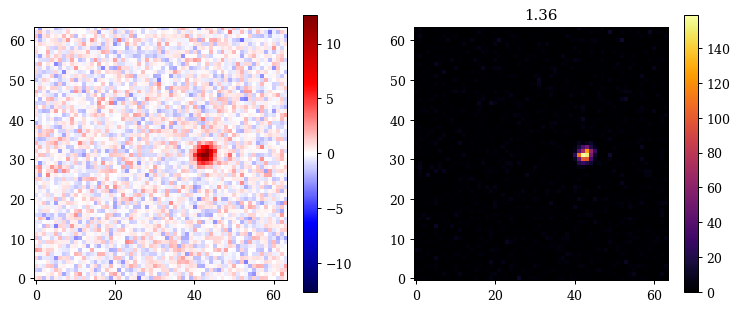

In [16]:
lamd = wavels.mean() / diameter
offset = lamd * np.array([3, 0])

#
primary = 1e8 * coron.propagate(wavels, weights=weights)
companion = 1e4 * coron.propagate(wavels, offset, weights=weights)
combined = primary + companion

#
photons = jr.poisson(jr.key(1), combined)
data = photons + read_noise * jr.normal(jr.key(2), combined.shape)
err = np.sqrt(combined + read_noise**2)

z_score = (data - primary) / err
chi2 = np.square(z_score).sum()
chi2r = chi2 / data.size

#
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(combined)
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(np.log10(combined))
plt.colorbar()
plt.show()

#
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow((data - primary) / err, seismic, norm=CenteredNorm())
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title(f"{chi2r:.2f}")
plt.imshow(((data - primary) / err) ** 2)
plt.colorbar()
plt.show()

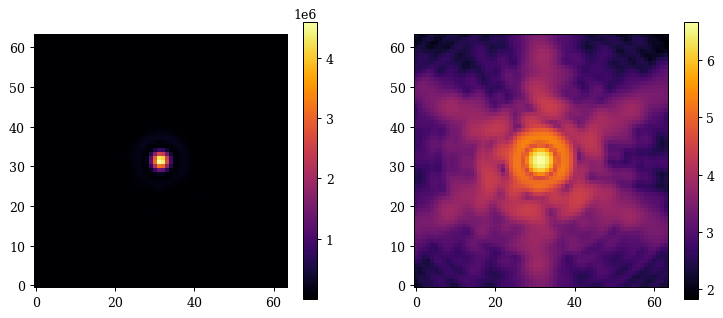

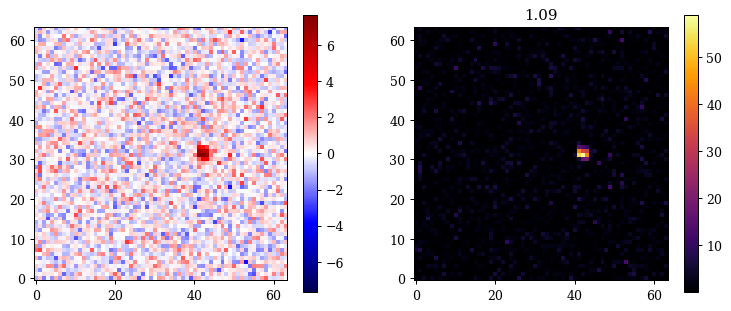

In [17]:
_optics = optics.multiply(coefficients=0.1)
primary = 1e8 * _optics.propagate(wavels, weights=weights)
companion = 1e4 * _optics.propagate(wavels, offset, weights=weights)
combined = primary + companion

#
photons = jr.poisson(jr.key(1), combined)
data = photons + read_noise * jr.normal(jr.key(2), combined.shape)
err = np.sqrt(combined + read_noise**2)

z_score = (data - primary) / err
chi2 = np.square(z_score).sum()
chi2r = chi2 / data.size

#
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(combined)
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(np.log10(combined))
plt.colorbar()
plt.show()

#
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow((data - primary) / err, seismic, norm=CenteredNorm())
plt.colorbar()

plt.subplot(1, 2, 2)
plt.title(f"{chi2r:.2f}")
plt.imshow(((data - primary) / err) ** 2)
plt.colorbar()
plt.show()

In [18]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

: 

: 

: 

: 

: 

: 

## Constructing a custom layer

In [ ]:
# Models some wavelengths through the system
wavels = 1e-6 * np.linspace(1, 1.2, 10)
psf = optics.propagate(wavels)

# Get out aperture transmission for plotting
# Note we can use the 'aperture' key we supplied in the layers to access
# that layer directly from the optics object!
transmission = optics.aperture.transmission

# Let examine the optics object! The dLux framework has in-built
# pretty-printing, so we can just print the object to see what it contains.
print(optics)

AngularOpticalSystem(
  wf_npixels=512,
  diameter=1.0,
  layers={
    'aperture': TransmissiveLayer(transmission=f32[512,512], normalise=True),
    'aberrations':
    BasisLayer(basis=f32[20,512,512], coefficients=f32[20], as_phase=False)
  },
  psf_npixels=64,
  oversample=1,
  psf_pixel_scale=0.05
)


: 

: 

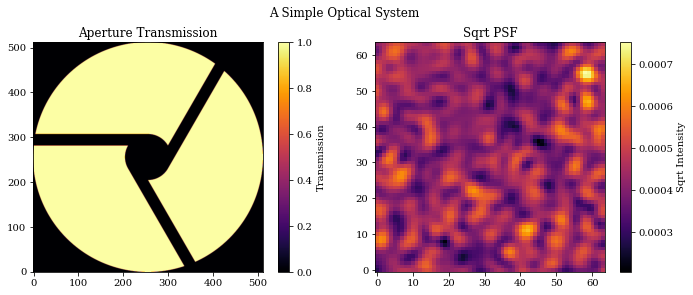

: 

: 

In [ ]:
# Plot the results
plt.figure(figsize=(10, 4))
plt.suptitle("A Simple Optical System")
plt.subplot(1, 2, 1)
plt.title("Aperture Transmission")
plt.imshow(transmission)
plt.colorbar(label="Transmission")

plt.subplot(1, 2, 2)
plt.title("Sqrt PSF")
plt.imshow(psf**0.5)
plt.colorbar(label="Sqrt Intensity")
plt.tight_layout()
plt.show()

## Adding Aberrations

It is very common for an optical system to have aberrations that have a significant impact on the psf, so lets see how we can model this!

In [ ]:
# First we define the zernike indices we want to model. In this example
# we ignore the even indices, as they suffer from a degeneracy that makes
# them difficult to recover when we have a symmetric aperture, like a circle!
indices = np.array([2, 3, 7, 8, 9, 10])

# Construct some zernike basis and some coefficients
basis = 1e-9 * dlu.zernike_basis(indices, coords, diameter=diameter)
coefficients = 50 * jr.normal(jr.PRNGKey(0), indices.shape)

# Re-define our layers to include the aberrations
layers = [
    (
        "aperture",
        dl.layers.TransmissiveLayer(transmission=aperture, normalise=True),
    ),
    (
        "aberrations",
        dl.layers.BasisLayer(basis=basis, coefficients=coefficients),
    ),
]

# Re-construct the optics object and re-propagate our wavelengths
optics = dl.AngularOpticalSystem(
    wf_npix, diameter, layers, psf_npix, psf_pixel_scale, oversample
)
psf = optics.propagate(wavels)

# Get out aperture aberrations for plotting
aberrations = optics.aberrations.eval_basis()

# Print the new object
print(optics)

TypeError: float() argument must be a string or a real number, not 'TransmissiveLayer'

: 

: 

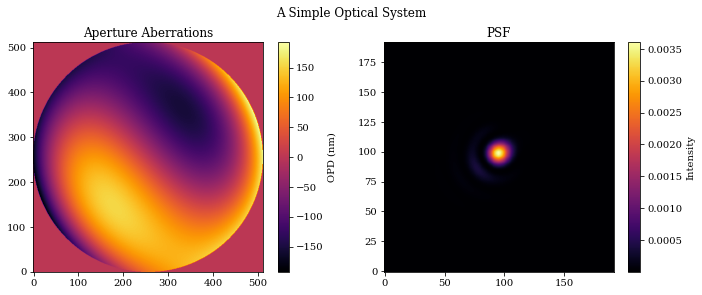

: 

: 

In [ ]:
# Plot the results
plt.figure(figsize=(10, 4))
plt.suptitle("A Simple Optical System")
plt.subplot(1, 2, 1)
plt.title("Aperture Aberrations")
plt.imshow(aberrations * 1e9)
plt.colorbar(label="OPD (nm)")

plt.subplot(1, 2, 2)
plt.title("PSF")
plt.imshow(psf)
plt.colorbar(label="Intensity")
plt.tight_layout()
plt.show()

## Working with dLux objects

`dLux` is build within `Zodiax`, which gives all classes a simple path-based way to interact with our objects. We will use this to set update the aberrations in our optical system, and then recover the values from the previous example!

There are two ways we can do this, either by setting the `aberrations.coefficients` values to a new array, or multiplying the current value by zero. We will show how to do both of these.

Note that we will call the new object `model` since we will use this object to try and recover the initial values we set.

In [ ]:
# Define our new coefficients and update the optics object
new_coefficients = np.zeros(coefficients.shape)
model = optics.set("aberrations.coefficients", new_coefficients)

# Multiply the existing coefficients by zero
model = optics.multiply("aberrations.coefficients", 0.0)

# New we can re-propagate our wavelengths to check that we have an 
# un-aberrated PSF
psf = model.propagate(wavels)

# Extract out values for plotting
aberrations = model.aberrations.eval_basis()

: 

: 

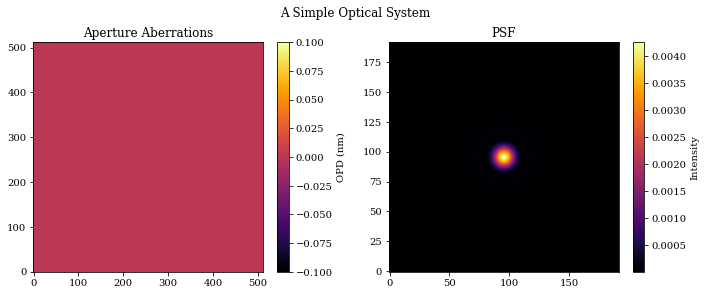

: 

: 

In [ ]:
# Plot the results
plt.figure(figsize=(10, 4))
plt.suptitle("A Simple Optical System")
plt.subplot(1, 2, 1)
plt.title("Aperture Aberrations")
plt.imshow(aberrations * 1e9)
plt.colorbar(label="OPD (nm)")

plt.subplot(1, 2, 2)
plt.title("PSF")
plt.imshow(psf)
plt.colorbar(label="Intensity")
plt.tight_layout()
plt.show()

## Taking Gradients

One of primary benefits of dLux is it is _differentiable_, meaning we can use autodiff to take gradients of any parameter in out model with respect to an arbitrary loss function.

To do this we will use `Zodiax`, which allows us to take gradients with respect to _specific_ parameters in our model, with a path-based interface. 

In [ ]:
# Generate some data to take gradients with respect to
flux = 1e4
data = jr.poisson(jr.PRNGKey(1), flux * optics.propagate(wavels))


# Define out loss function, in this case a simple poisson log-likelihood
@zdx.filter_value_and_grad("aberrations.coefficients")
def loss_fn(model, data):
    psf = flux * model.propagate(wavels)
    return -jsp.stats.poisson.logpmf(data, psf).mean()


# Now we evaluate the loss function and get the gradients
loss, grads = loss_fn(model, data)

# Note that Zodiax will return the gradients in the same structure as 
# the model, ie, an optics object! This means we can use all the same 
# methods to examine values as we would the normal optics object, so 
# lets have a look.
print(f"Loss: {loss}\n")
print(f"Coefficient gradients: {grads.aberrations.coefficients}\n")
print(f"Gradients object: {grads}")

Loss: 0.288269966840744

Coefficient gradients: [ 3.8819111e-05  1.4264378e-03 -6.6455011e-04 -1.2623395e-03
 -2.2182279e-04 -1.6320724e-05]

Gradients object: AngularOpticalSystem(
  wf_npixels=None,
  diameter=None,
  layers={
    'aperture':
    TransmissiveLayer(transmission=None, normalise=None),
    'aberrations':
    BasisLayer(basis=None, coefficients=f32[6], as_phase=None)
  },
  psf_npixels=None,
  oversample=None,
  psf_pixel_scale=None
)


: 

: 

## Compiling and Optimisation

Working within the `jax` framework allows us to compile our code to XLA, which can significantly speed up the execution of our code. Lets do this and see how fast out model is able to evaluate! `Zodiax` provides a simple interface that allows us to compile our _whole object_ to XLA using `zdx.filter_jit`, which is very convenient.

In [ ]:
# First we start by jit-compiling our loss function
jit_loss = zdx.filter_jit(loss_fn)

# Now lets have a look at the performance of the loss function
# Note we need to use the block_until_ready() method to ensure 
# the computation is timed correctly, this is because jax uses 
# asynchronous computation by default.
time_regular = %timeit -o loss_fn(model, data)[0].block_until_ready()
time_jit = %timeit -o jit_loss(model, data)[0].block_until_ready()

# Display timing results
print(f"Regular time: {time_regular.average*1e3:.5} ms")
print(f"Jit time: {time_jit.average*1e3:.5} ms")
print(f"Improvement: {time_regular.average/time_jit.average:.3}x faster")

113 ms ± 2.49 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
79.8 ms ± 1.33 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Regular time: 112.59 ms
Jit time: 79.843 ms
Improvement: 1.41x faster


: 

: 

Excellent, now that we have our compile loss function, lets optimise our model!

To do this we use `optax`, the gradient processing library developed by Googles DeepMind team. This library provides a number of optimisation algorithms, and we will use the `adam` optimiser here. `Zodiax` also provides a simple way to map our optimisation algorithms to our model, using `zdx.get_optimiser` function.

In [ ]:
# Construct our optimiser objects
optim, opt_state = zdx.get_optimiser(
    model, "aberrations.coefficients", optax.adam(1e1)
)

# Set up a progress bar
pbar = tqdm(range(50), desc="Loss: ")

# A basic optimisation loop
losses, models = [], []
for i in pbar:
    # Calculate the loss gradients, and update the model
    loss, grads = jit_loss(model, data)
    updates, opt_state = optim.update(grads, opt_state)
    model = zdx.apply_updates(model, updates)

    # save results
    models.append(model)
    losses.append(loss)

    pbar.set_description("Loss %.5f" % (loss))

Loss:   0%|          | 0/50 [00:00<?, ?it/s]

: 

: 

Now we visualise the results of our optimisation!

/var/folders/28/6s47s91d14ldjdrljs4d1hxw0000gn/T/ipykernel_39605/3478373043.py:48: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


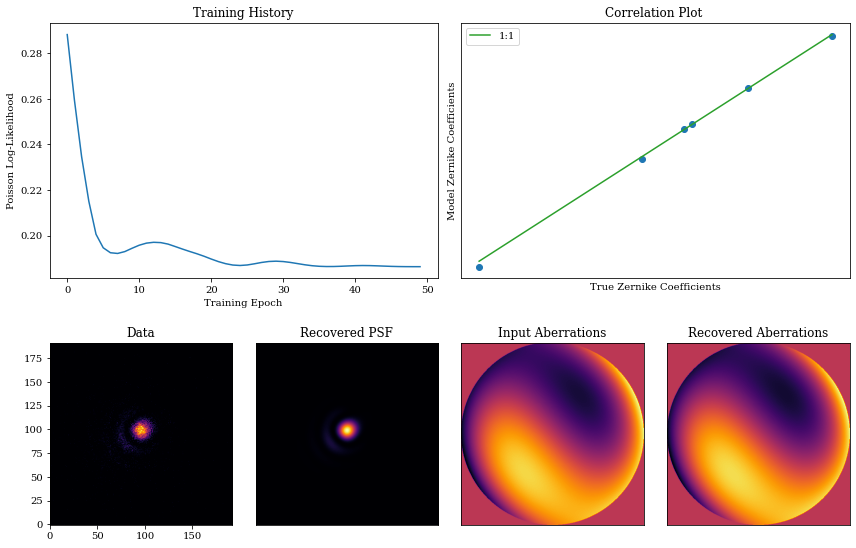

: 

: 

In [ ]:
psf = model.propagate(wavels)
coeffs_found = np.array([m.get("aberrations.coefficients") for m in models])
true_opd = optics.aberrations.eval_basis()
found_opd = model.aberrations.eval_basis()

mosaic = """
    AABB
    CDEF
    """

fig = plt.figure(constrained_layout=True, figsize=(12, 8))
axes = fig.subplot_mosaic(mosaic)

for ax in ["B", "D", "E", "F"]:
    axes[ax].set_xticks([])
    axes[ax].set_yticks([])

axes["A"].plot(np.array(losses))
axes["A"].set_title("Training History")
axes["A"].set_xlabel("Training Epoch")
axes["A"].set_ylabel("Poisson Log-Likelihood")

axes["B"].plot(coefficients, coeffs_found[-1], ".", markersize=12)
axes["B"].plot(
    np.array([np.min(coefficients), np.max(coefficients)]),
    np.array([np.min(coefficients), np.max(coefficients)]),
    "-",
    color="C2",
    label="1:1",
)
axes["B"].legend()
axes["B"].set_title("Correlation Plot ")
axes["B"].set_xlabel("True Zernike Coefficients")
axes["B"].set_ylabel("Model Zernike Coefficients")

axes["C"].imshow(data)
axes["C"].set_title("Data")

axes["D"].imshow(psf)
axes["D"].set_title("Recovered PSF")

axes["E"].imshow(true_opd)
axes["E"].set_title("Input Aberrations")

axes["F"].imshow(found_opd)
axes["F"].set_title("Recovered Aberrations")

fig.tight_layout()

There we go! We have successfully optimised our model to recover the initial values we set. This is a very simple example, but it shows the basic workflow of how to use dLux to optimise an optical system.

: 

: 